# 概率

---

## 练习2.6.1 

进行$m=500$组实验，每组抽取$n=10$个样本。改变$m$和$n$，观察和分析实验结果。

### &emsp;解答：

&emsp;&emsp;当每组抽取的样本数较少时，单组实验结果的波动会更大，因此通常需要进行更多组实验，估计概率才会逐渐稳定。相反，当每组抽取的样本数增大时，估计结果通常会更快收敛到真实概率。

In [1]:
import matplotlib.pyplot as plt
import torch
from torch.distributions import multinomial

In [2]:
fair_probs = torch.ones([6]) / 6
def experiment(ax, n=10, m=500, legend=1):
    counts = multinomial.Multinomial(n, fair_probs).sample((m,))
    cum_counts = counts.cumsum(dim=0)
    estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

    for i in range(6):
        ax.plot(estimates[:, i].numpy(),
                 label=("P(die=" + str(i + 1) + ")"))
    ax.set_title(f'n={n},m={m}')
    ax.axhline(y=0.167, color='black', linestyle='dashed')
    ax.set_xlabel('Groups of experiments')
    ax.set_ylabel('Estimated probability')
    if legend == 1:
        ax.legend()

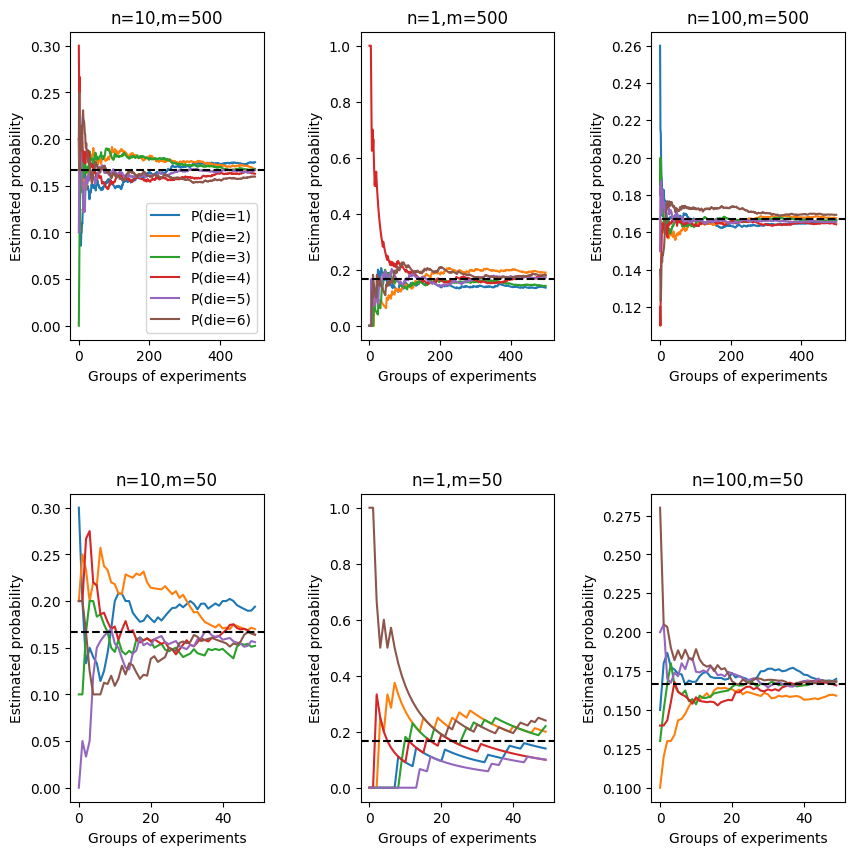

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.flatten()
experiment(axes[0])
experiment(axes[1], 1, 500, 0)
experiment(axes[2], 100, 500, 0)

experiment(axes[3], 10, 50, 0)
experiment(axes[4], 1, 50, 0)
experiment(axes[5], 100, 50, 0)
fig.subplots_adjust(wspace=0.5, hspace=0.5)

---

## 练习2.6.2 

给定两个概率为$P(\mathcal{A})$和$P(\mathcal{B})$的事件，计算$P(\mathcal{A} \cup \mathcal{B})$和$P(\mathcal{A} \cap \mathcal{B})$的上限和下限。（提示：使用[友元图](https://en.wikipedia.org/wiki/Venn_diagram)来展示这些情况。)

### &emsp;解答：

&emsp;&emsp;$P(\mathcal{A} \cap \mathcal{B})$的上限是 $ \min(P(\mathcal{A}), P(\mathcal{B}))$，两个事件交集的概率上限不会超过两者中较小的那个概率。$P(\mathcal{A} \cap \mathcal{B})$的下限是 $0$，因为两个事件可以互斥。

&emsp;&emsp;所以：
$$
0 \leqslant P(\mathcal{A} \cap \mathcal{B}) \leqslant \min (P(\mathcal{A}), P(\mathcal{B}))
$$

&emsp;&emsp;由于$P(\mathcal{A} \cup \mathcal{B})=P(\mathcal{A})+P( \mathcal{B})-P(\mathcal{A} \cap \mathcal{B})$，根据$P(\mathcal{A} \cap \mathcal{B})$的上下限，因此，$P(\mathcal{A} \cup \mathcal{B})$ 的取值范围为：

$$
\max(P(\mathcal{A}), P(\mathcal{B})) \leqslant P(\mathcal{A} \cup \mathcal{B}) \leqslant P(\mathcal{A}) + P(\mathcal{B})
$$

---

## 练习2.6.3

假设我们有一系列随机变量，例如$A$、$B$和$C$，其中$B$只依赖于$A$，而$C$只依赖于$B$，能简化联合概率$P(A, B, C)$吗？（提示：这是一个[马尔可夫链](https://en.wikipedia.org/wiki/Markov_chain)。)

### &emsp;解答：

&emsp;&emsp;根据题意，由于$B$只依赖于$A$，可知：
$$
P(B | A, C) = P(B | A)
$$
&emsp;&emsp;由于$C$只依赖于$B$，可知：
$$
P(C | A, B) = P(C | B)
$$

&emsp;&emsp;可得：
$$
\begin{aligned}
P(A, B, C)
&= P(C|A, B) P(A, B) \\
&= P(C|A, B) P(B|A) P(A) \\ 
&= P(C|B) P(B|A) P(A)
\end{aligned}
$$

&emsp;&emsp;则：
$$
P(A, B, C) = P(C | B) P(B | A) P(A)
$$

---

## 练习2.6.4

在2.6.2节中，第一个测试更准确。为什么不运行第一个测试两次，而是同时运行第一个和第二个测试？

### &emsp;解答：

&emsp;&emsp;如果将第一个测试独立地进行两次，并假设它们互不影响，则：

$$
\begin{aligned}
& P(D_1 = 1, D_1 = 1 \mid H = 1) \\ 
=& ( P(D_1 = 1 \mid H = 1))^2 \\
=& 1 
\end{aligned}
$$

$$
\begin{aligned}
&P(D_1 = 1, D_1 = 1) \\
=& P(D_1 = 1, D_1 = 1, H = 0) + P(D_1 = 1, D_1 = 1, H = 1) \\
=& P(D_1 = 1, D_1 = 1 \mid H = 0) P(H=0) + P(D_1 = 1, D_1 = 1 \mid H = 1) P(H=1) \\
=& (P(D_1 = 1 \mid H = 0))^2 P(H=0) +( P(D_1 = 1 \mid H = 1))^2 P(H=1)\\
=& (0.01)^2 \times 0.9985 + 1 \times 0.0015 \\
=& 0.00159985 \\
\end{aligned}
$$

$$
\begin{aligned}
&P( H = 1 \mid D_1 = 1, D_1 = 1) \\
=& \frac{P(D_1 = 1, D_1 = 1 \mid H = 1) P(H=1)}{P(D_1 = 1, D_1 = 1)} \\
=& \frac{1 \times 0.0015}{0.00159985} \\
=& 0.9375878988655186 \\
\end{aligned}
$$

&emsp;&emsp;根据得到的结果，高于同时运行第一个和第二个测试的概率值，但现实中我们不会让病人进行两次同种检验，另外如果进行相继两次的第一种测试，得到都为阳性的结果患者得病的概率为$1-(1-0.1307)^2 = 0.24431751000000002$